# Verificación del Bounding Model (v2_cost)

El `CostPredictorTransformer` fue entrenado con `np.log(cost)` como target.  
Para obtener el costo real estimado: `costo = exp(modelo(layout))`

**Nota**: este notebook solo usa Repo_Oscar + cpmp.layout. No importa CPMPTransformer
para evitar el conflicto entre los dos paquetes `generation`.

In [1]:
import sys, os, json, copy
import torch
import numpy as np

REPO_SRC = os.path.abspath('../Repo_Oscar/CPMP-Framework/src')
MAIN_SRC = os.path.abspath('../src')
MODEL_DIR = os.path.abspath('../models')

# Paso 1: Repo_Oscar primero → generation.adapters se cachea como paquete (directorio)
sys.path.insert(0, REPO_SRC)

from models.cost.cost_predictor_V2 import CostPredictorTransformer
from generation.adapters.input.enriched_layout_adapter import EnrichedLayoutAdapter
from generation.adapters.input.layout.layout_4D_adapter_V2 import Layout4DAdapterV2
from generation.adapters.input.stack_features.stack_features_adapter_V1 import StackFeaturesAdapterV1

# Paso 2: main src para cpmp (no toca generation, sin conflicto)
sys.path.insert(0, MAIN_SRC)
from cpmp.layout import read_file

print('Imports OK')

Imports OK


In [2]:
# Cargar bounding model (sin usar training.training del proyecto principal)
def load_bounding_model(model_name):
    hp_path = os.path.join(MODEL_DIR, 'hyperparameters', f'{model_name}.json')
    wt_path = os.path.join(MODEL_DIR, f'{model_name}.pth')
    with open(hp_path) as f:
        hp = json.load(f)
    model = CostPredictorTransformer(**hp)
    model.load_state_dict(torch.load(wt_path, weights_only=True, map_location='cpu'))
    model.eval()
    model.hyperparams = hp
    return model

bounding_model = load_bounding_model('v2_cost')
print(f'Modelo cargado: v2_cost')
print(f'Hiperparámetros: {bounding_model.hyperparams}')

Modelo cargado: v2_cost
Hiperparámetros: {'H_dim': 8, 'C_dim': 3, 'X_dim': 3, 'd_model': 64, 'nhead': 4, 'num_layers': 4, 'ff_dim_multiplier': 2, 'dropout': 0.3}


In [3]:
# Instanciar adapter
S_MAX, H_MAX = 10, 12

bounding_adapter = EnrichedLayoutAdapter(
    layout_adapter=Layout4DAdapterV2,
    stack_features_adapter=StackFeaturesAdapterV1,
    S_max=S_MAX,
    H_max=H_MAX
)
print(f'Adapter instanciado: S_max={S_MAX}, H_max={H_MAX}')

Adapter instanciado: S_max=10, H_max=12


In [4]:
def predict_cost(layout, H, model, adapter):
    device = next(model.parameters()).device
    with torch.no_grad():
        data = list(adapter.input_2_vec(layout, H))
        for i, val in enumerate(data):
            if isinstance(val, (int, float)):
                data[i] = torch.tensor([val]).to(device)
            else:
                data[i] = torch.from_numpy(val).unsqueeze(0).to(device)
        log_cost = model(*data)
        cost = torch.exp(log_cost).item()
    return log_cost.item(), cost

print('predict_cost definida')

predict_cost definida


## Test 1: Instancias pequeñas (3-3)
Se espera costo estimado bajo (1–5 movimientos).

In [5]:
CVS_PATH = '../instances/benchmarks/CVS'

folder, H_real = '3-3', 3
H_inf = H_real + 2

dat_files = sorted([
    os.path.join(CVS_PATH, folder, f)
    for f in os.listdir(os.path.join(CVS_PATH, folder)) if f.endswith('.dat')
])[:10]

print(f'Instancias {folder}  (H_inf={H_inf})')
print(f'{"Archivo":<30} {"log_cost":>10} {"exp(costo)":>12} {"sorted?":>8}')
print('-' * 65)

for path in dat_files:
    layout = read_file(path, H_inf)
    log_c, cost = predict_cost(layout, H_inf, bounding_model, bounding_adapter)
    print(f'{os.path.basename(path):<30} {log_c:>10.4f} {cost:>12.2f} {str(layout.is_sorted()):>8}')

Instancias 3-3  (H_inf=5)
Archivo                          log_cost   exp(costo)  sorted?
-----------------------------------------------------------------
data3-3-1.dat                      2.6047        13.53    False
data3-3-10.dat                     2.5668        13.02    False
data3-3-11.dat                     2.0542         7.80    False
data3-3-12.dat                     2.3918        10.93    False
data3-3-13.dat                     2.4684        11.80    False
data3-3-14.dat                     2.5051        12.24    False
data3-3-15.dat                     2.2655         9.64    False
data3-3-16.dat                     2.2829         9.80    False
data3-3-17.dat                     2.2032         9.05    False
data3-3-18.dat                     2.0692         7.92    False


## Test 2: Instancias medianas (6-6)
Se espera costo estimado mayor (10–40 movimientos).

In [6]:
folder, H_real = '6-6', 6
H_inf = H_real + 2

dat_files_66 = sorted([
    os.path.join(CVS_PATH, folder, f)
    for f in os.listdir(os.path.join(CVS_PATH, folder)) if f.endswith('.dat')
])[:10]

print(f'Instancias {folder}  (H_inf={H_inf})')
print(f'{"Archivo":<30} {"log_cost":>10} {"exp(costo)":>12} {"sorted?":>8}')
print('-' * 65)

for path in dat_files_66:
    layout = read_file(path, H_inf)
    log_c, cost = predict_cost(layout, H_inf, bounding_model, bounding_adapter)
    print(f'{os.path.basename(path):<30} {log_c:>10.4f} {cost:>12.2f} {str(layout.is_sorted()):>8}')

Instancias 6-6  (H_inf=8)
Archivo                          log_cost   exp(costo)  sorted?
-----------------------------------------------------------------
data6-6-1.dat                      3.6604        38.88    False
data6-6-10.dat                     3.5212        33.82    False
data6-6-11.dat                     3.7521        42.61    False
data6-6-12.dat                     3.6540        38.63    False
data6-6-13.dat                     3.6241        37.49    False
data6-6-14.dat                     3.6919        40.12    False
data6-6-15.dat                     3.7843        44.00    False
data6-6-16.dat                     3.5692        35.49    False
data6-6-17.dat                     3.8155        45.40    False
data6-6-18.dat                     3.8112        45.20    False


## Test 3: Layout ya ordenado → costo predicho debe ser ~0

Buscamos una instancia que ya esté resuelta (sorted=True), o creamos una trivial.

In [7]:
from cpmp.layout import Layout

# Crear un layout ya ordenado manualmente: 3 pilas, cada una con contenedores del mismo grupo
# En CPMP, sorted = todos los contenedores de una pila son del mismo grupo y el grupo más
# prioritario está arriba. Un layout trivialmente sorted: stacks con un solo contenedor c/u.
# Alternativa: buscar instancia sorted en el benchmark.

H_test = 5  # H_inf para instancias 3-x
sorted_found = None

for folder_name in ['3-3', '3-4', '3-5']:
    H_r = int(folder_name.split('-')[0])
    H_i = H_r + 2
    folder_path = os.path.join(CVS_PATH, folder_name)
    for f in os.listdir(folder_path):
        if not f.endswith('.dat'):
            continue
        layout = read_file(os.path.join(folder_path, f), H_i)
        if layout.is_sorted():
            sorted_found = (layout, H_i, folder_name, f)
            break
    if sorted_found:
        break

if sorted_found:
    layout_s, H_s, fold, fname = sorted_found
    log_c, cost = predict_cost(layout_s, H_s, bounding_model, bounding_adapter)
    print(f'Layout sorted encontrado: {fold}/{fname}')
    print(f'log_cost = {log_c:.4f}  →  exp(costo) = {cost:.4f}')
    print(f'Esperado: cercano a 0  →  {"OK" if cost < 1.5 else "REVISAR (valor alto)"}')
else:
    print('No se encontró instancia sorted en el benchmark CVS pequeño.')
    print('Comparando instancias 3-3 (simple) vs 6-6 (compleja) para verificar monotonía:')
    layout_small = read_file(dat_files[0], 5)
    layout_large = read_file(dat_files_66[0], 8)
    _, c_small = predict_cost(layout_small, 5, bounding_model, bounding_adapter)
    _, c_large = predict_cost(layout_large, 8, bounding_model, bounding_adapter)
    print(f'  3-3: {c_small:.2f} movimientos estimados')
    print(f'  6-6: {c_large:.2f} movimientos estimados')
    print(f'  Monotonía: {"OK (3-3 < 6-6)" if c_small < c_large else "REVISAR"}')

Layout sorted encontrado: 3-3/data3-3-39.dat
log_cost = 0.3851  →  exp(costo) = 1.4697
Esperado: cercano a 0  →  OK


## Test 4: Distribución de costos predichos por categoría

Verificamos que el modelo escala razonablemente: instancias más grandes → costos mayores.

Categoria       N    Media      Min      Max
---------------------------------------------
3-3            20    10.96     6.29    15.41
3-4            20    10.04     5.64    14.02
3-5            20    11.43     8.61    15.58
4-4            20    17.53    11.97    22.33
4-5            20    19.36    14.97    23.05
5-5            20    27.65    23.87    34.70
6-6            20    41.38    33.82    45.40


/tmp/ipykernel_10218/3427132344.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_plot, labels=labels_plot)


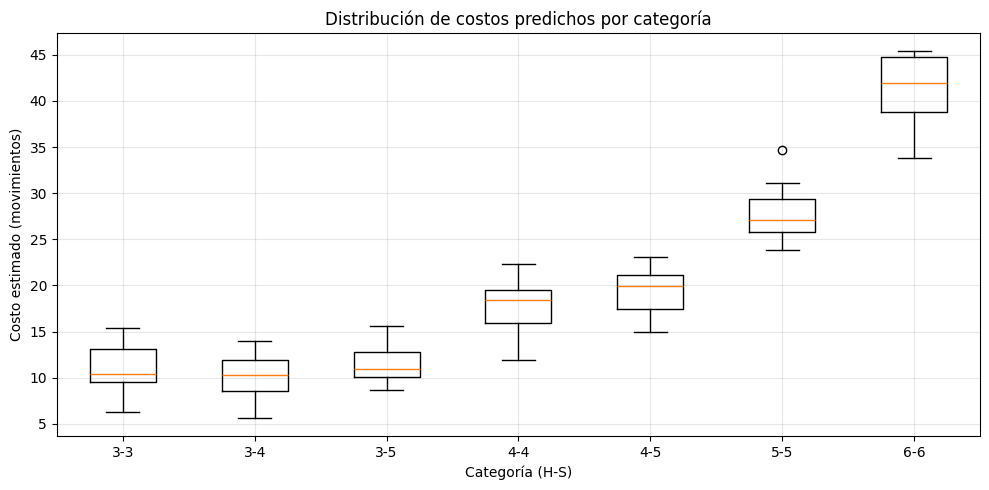


Esperado: costos crecen con el tamaño de la instancia.
Monotonicidad de medias: No estrictamente monótono (puede ser normal)


In [8]:
import matplotlib.pyplot as plt

categorias = ['3-3', '3-4', '3-5', '4-4', '4-5', '5-5', '6-6']
resultados = {}

for folder_name in categorias:
    H_r = int(folder_name.split('-')[0])
    H_i = H_r + 2
    folder_path = os.path.join(CVS_PATH, folder_name)
    if not os.path.isdir(folder_path):
        continue

    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.dat')])[:20]
    costos = []
    for f in files:
        layout = read_file(os.path.join(folder_path, f), H_i)
        if layout.is_sorted():
            continue
        _, cost = predict_cost(layout, H_i, bounding_model, bounding_adapter)
        costos.append(cost)

    resultados[folder_name] = costos

# Tabla resumen
print(f'{"Categoria":<12} {"N":>4} {"Media":>8} {"Min":>8} {"Max":>8}')
print('-' * 45)
for cat, costos in resultados.items():
    if costos:
        print(f'{cat:<12} {len(costos):>4} {np.mean(costos):>8.2f} {np.min(costos):>8.2f} {np.max(costos):>8.2f}')

# Boxplot por categoría
fig, ax = plt.subplots(figsize=(10, 5))
data_plot = [resultados[c] for c in categorias if c in resultados and resultados[c]]
labels_plot = [c for c in categorias if c in resultados and resultados[c]]
ax.boxplot(data_plot, labels=labels_plot)
ax.set_xlabel('Categoría (H-S)')
ax.set_ylabel('Costo estimado (movimientos)')
ax.set_title('Distribución de costos predichos por categoría')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nEsperado: costos crecen con el tamaño de la instancia.')
medias = [np.mean(resultados[c]) for c in categorias if c in resultados and resultados[c]]
monotono = all(medias[i] <= medias[i+1] for i in range(len(medias)-1))
print(f'Monotonicidad de medias: {"OK" if monotono else "No estrictamente monótono (puede ser normal)"}')